# Análisis de prototipos y espacio latente
**Modelos:** B30 (PrototypeDL), ProtoVAE, SENN  
**Contenido:** carga de modelos → selección → visualización de prototipos → PCA del espacio latente

> Ejecutar las celdas en orden. Para cambiar el modelo analizado, modificar solo la **Celda 2**.

In [1]:
# ── Imports & paths ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.decomposition import PCA
import json, os
from types import SimpleNamespace
from pathlib import Path

from data_loader import get_test_loader
from ProtoVAE import model as model_protovae
from ProtoVAE import settings as protovae_settings
from SENN.models.senn import SENN
from SENN.models.conceptizers import *   # noqa
from SENN.models.parameterizers import * # noqa
from SENN.models.aggregators import *    # noqa

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Paths ────────────────────────────────────────────────────────────────────
B30_BASE_CKPT = 'saved_model/mnist_model/mnist_cae_balanced_clstsep_1500_0.002_250_True_0.0_20_1_1_1_1.0_0.0_30_4_32_1/mnist_cae00750.pth'
SENN_CKPT     = 'SENN/results/mnist_lambda1e-2_seed29/checkpoints/best_model.pt'
SENN_CONFIG   = 'SENN/configs/mnist_lambda1e-2_seed29.json'
PROTOVAE_CKPT = 'ProtoVAE/saved_models/mnist/model.pth'
TFG_ROOT      = 'tfg_models'

ALL_MODELS = {
    # ── Baselines ──────────────────────────────────────────────────────────
    'B30':           {'type': 'b30',         'ckpt': B30_BASE_CKPT},
    'ProtoVAE':      {'type': 'protovae',    'ckpt': PROTOVAE_CKPT},
    'SENN_0_01':     {'type': 'senn',        'ckpt': SENN_CKPT},
    # ── B30 fine-tuned ─────────────────────────────────────────────────────
    'B30-FT-0':      {'type': 'b30_ft', 'ckpt': f'{TFG_ROOT}/B30/B30-FT-0/seed=1/checkpoints/B30_B30-FT-0_seed1_best_val_adv_acc.pth'},
    'B30-FT-1':      {'type': 'b30_ft', 'ckpt': f'{TFG_ROOT}/B30/B30-FT-1/seed=1/checkpoints/B30_B30-FT-1_seed1_best_val_adv_acc.pth'},
    'B30-FT-2':      {'type': 'b30_ft', 'ckpt': f'{TFG_ROOT}/B30/B30-FT-2/seed=1/checkpoints/B30_B30-FT-2_seed1_best_val_adv_acc.pth'},
    'B30-FT-3':      {'type': 'b30_ft', 'ckpt': f'{TFG_ROOT}/B30/B30-FT-3/seed=1/checkpoints/B30_B30-FT-3_seed1_best_val_adv_acc.pth'},
    'B30-FT-E':      {'type': 'b30_ft', 'ckpt': f'{TFG_ROOT}/B30/B30-FT-E/seed=1/checkpoints/B30_B30-FT-E_seed1_best_val_adv_acc.pth'},
    # ── ProtoVAE fine-tuned ────────────────────────────────────────────────
    'ProtoVAE-FT-0': {'type': 'protovae_ft', 'ckpt': f'{TFG_ROOT}/ProtoVAE/ProtoVAE-FT-0/seed=1/checkpoints/ProtoVAE_ProtoVAE-FT-0_seed1_best_val_adv_acc.pth'},
    'ProtoVAE-FT-1': {'type': 'protovae_ft', 'ckpt': f'{TFG_ROOT}/ProtoVAE/ProtoVAE-FT-1/seed=1/checkpoints/ProtoVAE_ProtoVAE-FT-1_seed1_best_val_adv_acc.pth'},
    'ProtoVAE-FT-2': {'type': 'protovae_ft', 'ckpt': f'{TFG_ROOT}/ProtoVAE/ProtoVAE-FT-2/seed=1/checkpoints/ProtoVAE_ProtoVAE-FT-2_seed1_best_val_adv_acc.pth'},
    'ProtoVAE-FT-3': {'type': 'protovae_ft', 'ckpt': f'{TFG_ROOT}/ProtoVAE/ProtoVAE-FT-3/seed=1/checkpoints/ProtoVAE_ProtoVAE-FT-3_seed1_best_val_adv_acc.pth'},
    'ProtoVAE-FT-E': {'type': 'protovae_ft', 'ckpt': f'{TFG_ROOT}/ProtoVAE/ProtoVAE-FT-E/seed=1/checkpoints/ProtoVAE_ProtoVAE-FT-E_seed1_best_val_adv_acc.pth'},
    # ── SENN fine-tuned ────────────────────────────────────────────────────
    'SENN-FT-0':     {'type': 'senn_ft', 'ckpt': f'{TFG_ROOT}/SENN_0_01/SENN-FT-0/seed=1/checkpoints/SENN_0_01_SENN-FT-0_seed1_best_val_adv_acc.pth'},
    'SENN-FT-1':     {'type': 'senn_ft', 'ckpt': f'{TFG_ROOT}/SENN_0_01/SENN-FT-1/seed=1/checkpoints/SENN_0_01_SENN-FT-1_seed1_best_val_adv_acc.pth'},
    'SENN-FT-2':     {'type': 'senn_ft', 'ckpt': f'{TFG_ROOT}/SENN_0_01/SENN-FT-2/seed=1/checkpoints/SENN_0_01_SENN-FT-2_seed1_best_val_adv_acc.pth'},
}

print(f'Modelos disponibles ({len(ALL_MODELS)}): {list(ALL_MODELS.keys())}')

Device: cpu
Modelos disponibles (16): ['B30', 'ProtoVAE', 'SENN_0_01', 'B30-FT-0', 'B30-FT-1', 'B30-FT-2', 'B30-FT-3', 'B30-FT-E', 'ProtoVAE-FT-0', 'ProtoVAE-FT-1', 'ProtoVAE-FT-2', 'ProtoVAE-FT-3', 'ProtoVAE-FT-E', 'SENN-FT-0', 'SENN-FT-1', 'SENN-FT-2']


In [2]:
# ── SENN instantiation helper ────────────────────────────────────────────────
def _load_senn_arch(path, dev):
    with open(path) as f:
        cfg = json.load(f)
    cfg['device'] = str(dev)
    cfg = SimpleNamespace(**cfg)
    conceptizer   = eval(cfg.conceptizer)(**cfg.__dict__)
    parameterizer = eval(cfg.parameterizer)(**cfg.__dict__)
    aggregator    = eval(cfg.aggregator)(**cfg.__dict__)
    return SENN(conceptizer, parameterizer, aggregator)

# ── Generic model loader ──────────────────────────────────────────────────────
def load_model(name):
    """Carga cualquier modelo de ALL_MODELS. Devuelve (model, model_type)."""
    cfg   = ALL_MODELS[name]
    mtype = cfg['type']
    ckpt  = cfg['ckpt']

    if mtype == 'b30':
        model = torch.load(ckpt, map_location=device, weights_only=False)

    elif mtype == 'b30_ft':
        model = torch.load(B30_BASE_CKPT, map_location=device, weights_only=False)
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state['model_state'])

    elif mtype == 'protovae':
        model = model_protovae.ProtoVAE().to(device)
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state)

    elif mtype == 'protovae_ft':
        model = model_protovae.ProtoVAE().to(device)
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state['model_state'])

    elif mtype in ('senn', 'senn_ft'):
        model = _load_senn_arch(SENN_CONFIG, device)
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state['model_state'])

    else:
        raise ValueError(f'Tipo desconocido: {mtype}')

    model = model.to(device).eval()
    return model, mtype

# ── Dataset ──────────────────────────────────────────────────────────────────
DATA_DIR    = 'data'
BATCH_SIZE  = 256
test_loader = get_test_loader(DATA_DIR, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f'Test loader listo: {len(test_loader)} batches  ({len(test_loader.dataset)} muestras)')

Test loader listo: 40 batches  (10000 muestras)


In [3]:
# ── Funciones de codificación por tipo ───────────────────────────────────────
# Todas devuelven (Z: np.ndarray [N, D], labels: np.ndarray [N])

@torch.no_grad()
def encode_b30(model, loader):
    """B30: model.encoder(x) -> flatten."""
    zs, ys = [], []
    for x, y in loader:
        x = x.to(device)
        z = model.encoder(x).view(x.size(0), -1)
        zs.append(z.cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(zs), np.concatenate(ys)

@torch.no_grad()
def encode_protovae(model, loader):
    """ProtoVAE: mu del encoder VAE (determinista, sin reparametrización)."""
    latent = protovae_settings.latent
    zs, ys = [], []
    for x, y in loader:
        x    = (x * 2 - 1).to(device)   # [0,1] -> [-1,1]
        feats = model.features(x)         # [B, latent*2]
        mu    = feats[:, :latent]          # [B, latent]
        zs.append(mu.cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(zs), np.concatenate(ys)

@torch.no_grad()
def encode_senn(model, loader):
    """SENN: conceptos h(x) del conceptizer -> flatten."""
    zs, ys = [], []
    for x, y in loader:
        x = (x * 2 - 1).to(device)
        concepts, _ = model.conceptizer(x)   # [B, n_concepts, 1]
        z = concepts.view(x.size(0), -1)
        zs.append(z.cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(zs), np.concatenate(ys)

def get_encoder_fn(mtype):
    if mtype in ('b30', 'b30_ft'):         return encode_b30
    if mtype in ('protovae', 'protovae_ft'): return encode_protovae
    if mtype in ('senn', 'senn_ft'):       return encode_senn
    raise ValueError(mtype)

CMAP   = plt.cm.get_cmap('tab10', 10)
COLORS = [CMAP(i) for i in range(10)]
print('Helpers de codificación listos.')

Helpers de codificación listos.


C:\Users\hugor\AppData\Local\Temp\ipykernel_6420\1890900944.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  CMAP   = plt.cm.get_cmap('tab10', 10)


---
## Celda 2 — Selección del modelo a analizar
Modifica `MODEL_NAME` y re-ejecuta esta celda y las siguientes.

| Valor | Descripción |
|-------|-------------|
| `'B30'` | PrototypeDL baseline |
| `'B30-FT-0'` … `'B30-FT-E'` | PrototypeDL fine-tuneado |
| `'ProtoVAE'` / `'ProtoVAE-FT-*'` | ProtoVAE baseline / fine-tuneado |
| `'SENN_0_01'` / `'SENN-FT-*'` | SENN baseline / fine-tuneado |

In [11]:
# ── CAMBIA AQUÍ ──────────────────────────────────────────────────────────────
MODEL_NAME = 'B30'  # Elige un modelo de ALL_MODELS para cargar y codificar
# ─────────────────────────────────────────────────────────────────────────────

assert MODEL_NAME in ALL_MODELS, f'{MODEL_NAME} no está en ALL_MODELS'
model, mtype = load_model(MODEL_NAME)
total = sum(p.numel() for p in model.parameters())
print(f'Modelo: {MODEL_NAME}  |  Tipo: {mtype}  |  Params: {total:,}')

Modelo: B30  |  Tipo: b30  |  Params: 44,903


---
## Celda 3 — Visualización de prototipos
- **B30 / B30-FT-\***: `prototype_layer.prototype_distances` → `decoder` (30 prototipos)
- **ProtoVAE / ProtoVAE-FT-\***: `prototype_vectors` → `decoder` (50 prototipos)
- **SENN / SENN-FT-\***: no tiene prototipos explícitos; se muestran las reconstrucciones del conceptizer sobre un batch del test set

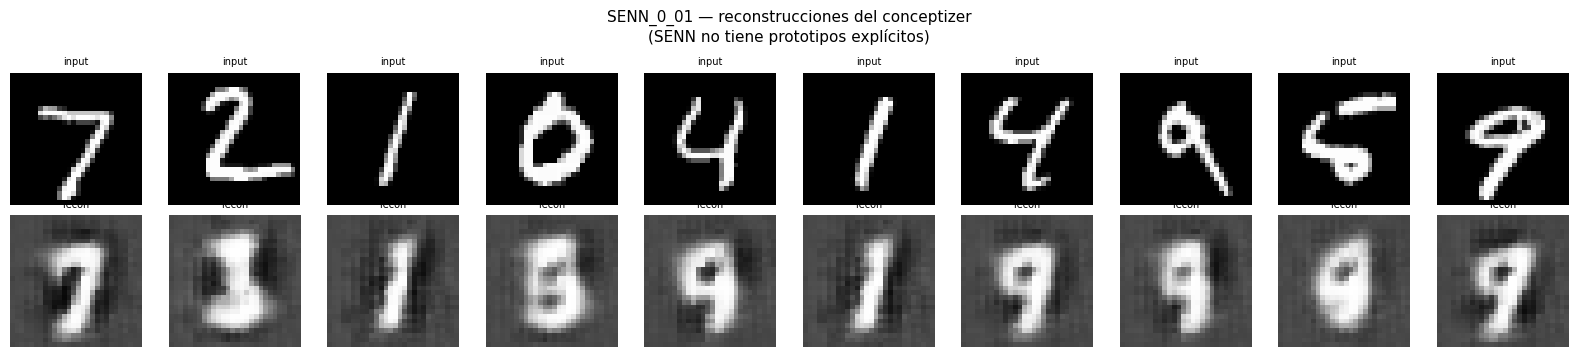

In [10]:
# ── Helpers de extracción de imágenes ────────────────────────────────────────
@torch.no_grad()
def get_proto_imgs_b30(m):
    pd   = m.prototype_layer.prototype_distances.to(device)
    imgs = m.decoder(pd.reshape(-1, 10, 2, 2)).cpu()
    return imgs   # [K, 1, 28, 28]  values in [-1,1] after tanh? clamp below

@torch.no_grad()
def get_proto_imgs_protovae(m):
    pvecs = m.prototype_vectors           # [K, latent]
    imgs  = m.decoder(pvecs).cpu()        # tanh -> [-1,1]
    return ((imgs + 1) / 2).clamp(0, 1)  # -> [0,1]

@torch.no_grad()
def get_concept_recons_senn(m, loader, n=10):
    x, _ = next(iter(loader))
    x_in = (x[:n] * 2 - 1).to(device)
    _, recon = m.conceptizer(x_in)
    recon = ((recon.cpu() + 1) / 2).clamp(0, 1)
    return x[:n], recon


# ── Plot ─────────────────────────────────────────────────────────────────────
def plot_prototypes(m, mt, name, cols=10):
    is_senn = mt in ('senn', 'senn_ft')

    if is_senn:
        x_orig, recons = get_concept_recons_senn(m, test_loader, n=10)
        n = len(x_orig)
        fig, axes = plt.subplots(2, n, figsize=(n * 1.6, 3.6))
        fig.suptitle(f'{name} — reconstrucciones del conceptizer\n'
                     '(SENN no tiene prototipos explícitos)', fontsize=11)
        for i in range(n):
            axes[0, i].imshow(x_orig[i, 0], cmap='gray', vmin=0, vmax=1)
            axes[0, i].axis('off')
            axes[0, i].set_title('input', fontsize=7)
            axes[1, i].imshow(recons[i, 0], cmap='gray', vmin=0, vmax=1)
            axes[1, i].axis('off')
            axes[1, i].set_title('recon', fontsize=7)
        plt.tight_layout(); plt.show(); return

    imgs = get_proto_imgs_b30(m) if 'b30' in mt else get_proto_imgs_protovae(m)
    K    = imgs.shape[0]
    rows = (K + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.5))
    axes = np.array(axes).reshape(rows, cols)
    fig.suptitle(f'{name} — {K} prototipos decodificados', fontsize=12, y=1.02)
    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        if i < K:
            ax.imshow(imgs[i, 0].clamp(0, 1).numpy(), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'P{i}', fontsize=7)
        ax.axis('off')
    plt.tight_layout(); plt.show()


plot_prototypes(model, mtype, MODEL_NAME)

---
## Celda 4 — PCA del espacio latente
Proyecta las 10 000 representaciones latentes del test set en 2D mediante PCA.
Los prototipos (B30, ProtoVAE) se superponen como miniaturas en el espacio proyectado.

**PCA vs UMAP:**  
PCA es determinista y lineal — los ejes son comparables entre modelos del mismo tipo (e.g. B30 baseline vs B30-FT-0). UMAP da clusters más nítidos visualmente pero sus ejes cambian en cada ejecución. La Celda 5 ofrece UMAP como alternativa cualitativa.

Varianza explicada — PC1: 20.8%  PC2: 19.1%  Total: 39.9%


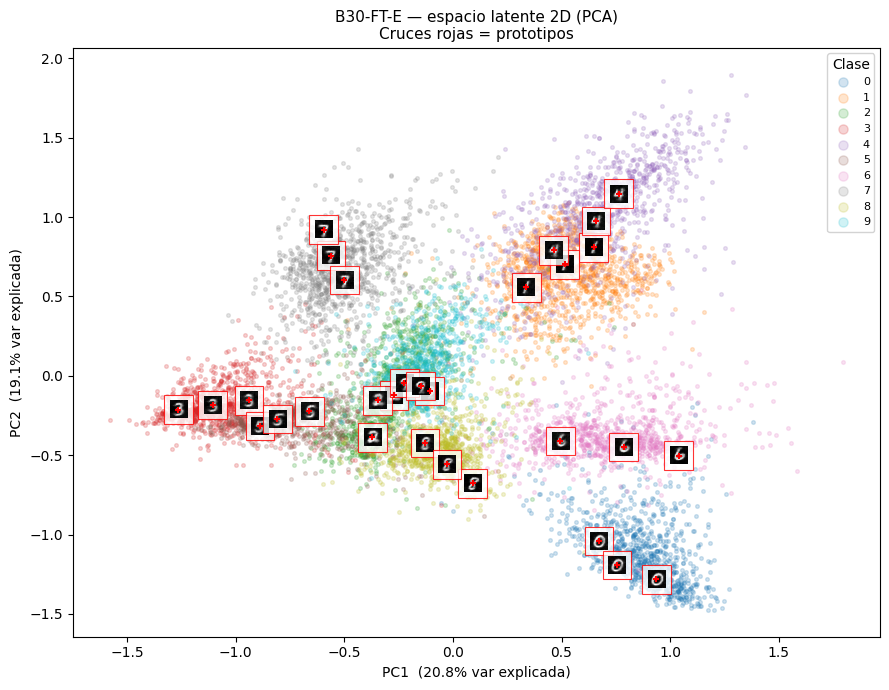

In [6]:
# ── Parámetros ───────────────────────────────────────────────────────────────
PROTO_ZOOM = 0.45    # zoom de las miniaturas de prototipos en el scatter
N_SAMPLES  = None    # None = todos los 10 000; int para ir más rápido
ALPHA      = 0.20    # transparencia de los puntos del scatter
POINT_SIZE = 7


def fit_pca(m, mt, loader, n_samples=None):
    """Codifica el test set y ajusta PCA 2D. Devuelve (Z2d, labels, pca)."""
    encode_fn = get_encoder_fn(mt)
    Z, labels = encode_fn(m, loader)
    if n_samples:
        idx = np.random.choice(len(Z), n_samples, replace=False)
        Z, labels = Z[idx], labels[idx]
    pca = PCA(n_components=2)
    Z2d = pca.fit_transform(Z)
    var = pca.explained_variance_ratio_
    print(f'Varianza explicada — PC1: {var[0]*100:.1f}%  '
          f'PC2: {var[1]*100:.1f}%  Total: {(var.sum())*100:.1f}%')
    return Z2d, labels, pca


@torch.no_grad()
def _get_proto_latents(m, mt):
    """Devuelve (proto_Z [K, D], proto_imgs [K, 1, H, W])."""
    if 'b30' in mt:
        pd   = m.prototype_layer.prototype_distances.to(device)
        imgs = ((m.decoder(pd.reshape(-1, 10, 2, 2)).cpu() + 1) / 2).clamp(0, 1)
        return pd.cpu().numpy().reshape(-1, 40), imgs
    else:  # protovae
        pvecs = m.prototype_vectors
        imgs  = ((m.decoder(pvecs).cpu() + 1) / 2).clamp(0, 1)
        return pvecs.cpu().numpy(), imgs


def plot_pca(Z2d, labels, pca, m, mt, name):
    fig, ax = plt.subplots(figsize=(9, 7))
    var = pca.explained_variance_ratio_

    # Scatter por clase
    for c in range(10):
        mask = labels == c
        ax.scatter(Z2d[mask, 0], Z2d[mask, 1],
                   color=COLORS[c], alpha=ALPHA, s=POINT_SIZE,
                   label=str(c), rasterized=True)

    # Prototipos superpuestos (solo B30 y ProtoVAE)
    has_protos = mt not in ('senn', 'senn_ft')
    if has_protos:
        proto_Z, proto_imgs = _get_proto_latents(m, mt)
        proto_2d = pca.transform(proto_Z)
        for i, (px, py) in enumerate(proto_2d):
            img = proto_imgs[i, 0].clamp(0, 1).numpy()
            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())
            oi  = OffsetImage(img, cmap='gray', zoom=PROTO_ZOOM)
            ab  = AnnotationBbox(oi, (px, py), frameon=True,
                                 bboxprops=dict(edgecolor='red', linewidth=0.8, alpha=0.8))
            ax.add_artist(ab)
            ax.scatter(px, py, c='red', s=20, zorder=10, marker='+')

    ax.set_xlabel(f'PC1  ({var[0]*100:.1f}% var explicada)', fontsize=10)
    ax.set_ylabel(f'PC2  ({var[1]*100:.1f}% var explicada)', fontsize=10)
    subtitle = 'Cruces rojas = prototipos' if has_protos else 'Espacio de conceptos h(x)'
    ax.set_title(f'{name} — espacio latente 2D (PCA)\n{subtitle}', fontsize=11)
    ax.legend(title='Clase', fontsize=8, markerscale=2.5, loc='best', framealpha=0.85)
    plt.tight_layout()
    plt.show()


Z2d, labels, pca = fit_pca(model, mtype, test_loader, n_samples=N_SAMPLES)
plot_pca(Z2d, labels, pca, model, mtype, MODEL_NAME)

---
## Celda 5 (opcional) — UMAP
Mejor separación visual de clases, pero **no comparable entre ejecuciones ni modelos**.
Usar solo para visualización cualitativa.  
Requiere: `pip install umap-learn`

In [7]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


c:\Users\hugor\anaconda3\envs\tfg\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP ajustado.


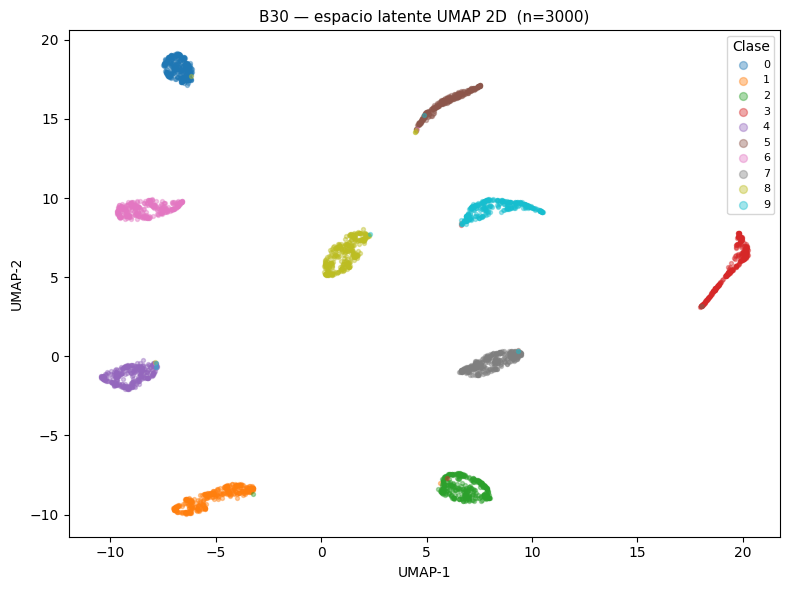

In [12]:
try:
    import umap as umap_lib
except ImportError:
    print('UMAP no instalado. Ejecuta: pip install umap-learn')
    raise

UMAP_N   = 3000   # subconjunto para velocidad
UMAP_SEED = 42

encode_fn = get_encoder_fn(mtype)
Z_full, lab_full = encode_fn(model, test_loader)

rng = np.random.default_rng(UMAP_SEED)
idx = rng.choice(len(Z_full), UMAP_N, replace=False)
Z_sub, lab_sub = Z_full[idx], lab_full[idx]

reducer = umap_lib.UMAP(n_components=2, random_state=UMAP_SEED,
                        n_neighbors=30, min_dist=0.1)
Z_umap  = reducer.fit_transform(Z_sub)
print('UMAP ajustado.')

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(10):
    mask = lab_sub == c
    ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
               color=COLORS[c], alpha=0.4, s=8, label=str(c), rasterized=True)
ax.set_title(f'{MODEL_NAME} — espacio latente UMAP 2D  (n={UMAP_N})', fontsize=11)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(title='Clase', fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()

---
## Celda 6 (opcional) — Comparación directa entre dos modelos
Muestra el PCA de dos modelos del **mismo tipo** en subplots paralelos.  
Útil para ver el efecto del fine-tuning en el espacio latente.

Varianza explicada — PC1: 15.3%  PC2: 13.9%  Total: 29.1%
Varianza explicada — PC1: 15.6%  PC2: 14.0%  Total: 29.6%


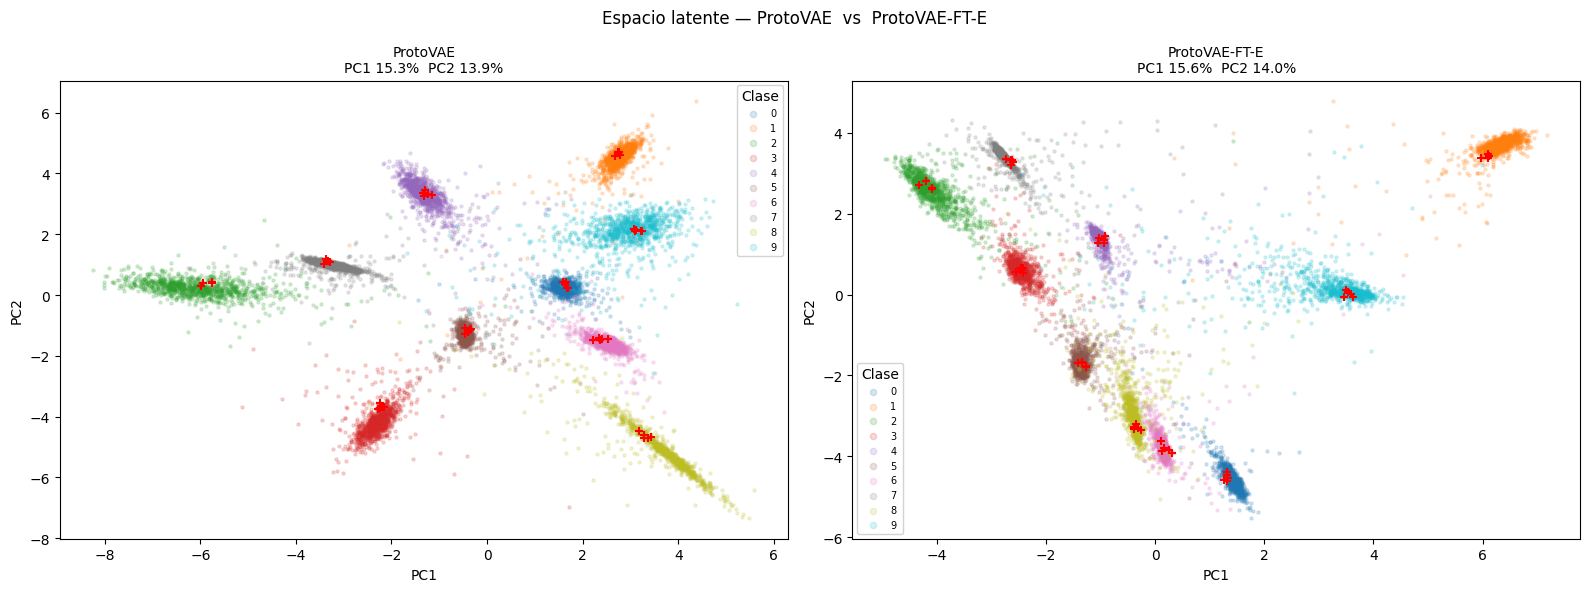

In [19]:
# ── Configura los dos modelos a comparar ─────────────────────────────────────
MODEL_A = 'ProtoVAE'
MODEL_B = 'ProtoVAE-FT-E'
# ─────────────────────────────────────────────────────────────────────────────

def _family(mt):
    return mt.replace('_ft', '')

mtA = ALL_MODELS[MODEL_A]['type']
mtB = ALL_MODELS[MODEL_B]['type']
assert _family(mtA) == _family(mtB), \
    f'Para comparación directa ambos modelos deben ser del mismo tipo: {mtA} vs {mtB}'

mA, mtA = load_model(MODEL_A)
mB, mtB = load_model(MODEL_B)

ZA, lA, pcaA = fit_pca(mA, mtA, test_loader)
ZB, lB, pcaB = fit_pca(mB, mtB, test_loader)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 6))

for ax, Z2d, labs, m, mt, pca_obj, name in [
    (axA, ZA, lA, mA, mtA, pcaA, MODEL_A),
    (axB, ZB, lB, mB, mtB, pcaB, MODEL_B),
]:
    for c in range(10):
        mask = labs == c
        ax.scatter(Z2d[mask, 0], Z2d[mask, 1],
                   color=COLORS[c], alpha=0.18, s=5, label=str(c), rasterized=True)

    if mt not in ('senn', 'senn_ft'):
        pZ, pI = _get_proto_latents(m, mt)
        p2d    = pca_obj.transform(pZ)
        for px, py in p2d:
            ax.scatter(px, py, c='red', s=35, zorder=10, marker='+')

    var = pca_obj.explained_variance_ratio_
    ax.set_title(f'{name}\nPC1 {var[0]*100:.1f}%  PC2 {var[1]*100:.1f}%', fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(title='Clase', fontsize=7, markerscale=2, loc='best', framealpha=0.85)

fig.suptitle(f'Espacio latente — {MODEL_A}  vs  {MODEL_B}', fontsize=12)
plt.tight_layout()
plt.show()